/var/folders/vf/2jyv6tlx4fq_b5yck9lsvwlh0000gn/T/ipykernel_50080/3566179027.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/var/folders/vf/2jyv6tlx4fq_b5yck9lsvwlh0000gn/T/ipykernel_50080/3566179027.py:87: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


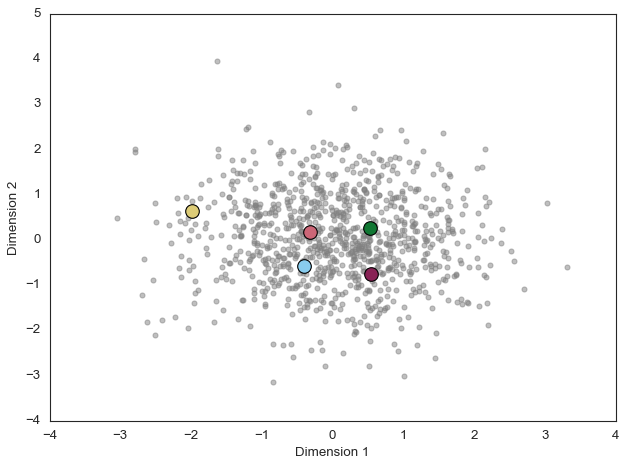

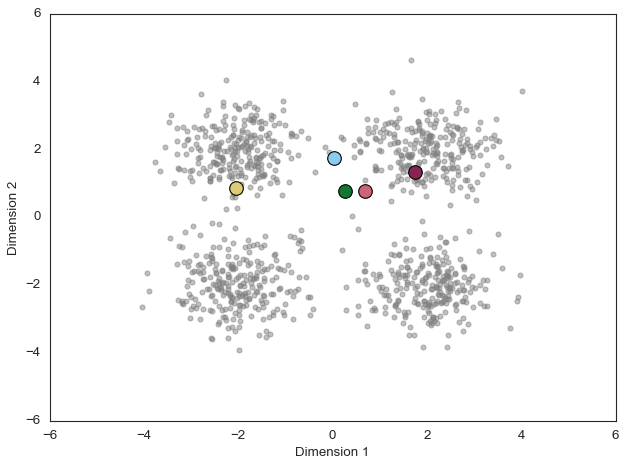

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Set a style and random seed for reproducibility.
sns.set_style('white')
np.random.seed(1)

# -------------------------------
# Figure 1: Gaussian Population
# -------------------------------
n_points = 1000  # number of individuals in the population

# Generate a homogeneous (bivariate normal) population.
pop_mean_true = [0, 0]
pop_cov = [[1, 0], [0, 1]]
population = np.random.multivariate_normal(pop_mean_true, pop_cov, n_points)

# Compute the sample population mean (close to zero).
pop_mean = population.mean(axis=0)

# Structured Noise Model:
num_parties = 5
noise_sigma = 1
party_points = []
for i in range(num_parties):
    error = np.random.multivariate_normal([0, 0], [[noise_sigma**2, 0], [0, noise_sigma**2]])
    party_points.append(pop_mean + error)
party_points = np.array(party_points)

# Create the plot.
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.scatter(population[:, 0], population[:, 1], color='gray', alpha=0.5, s=20, label='Population')

# Get a qualitative colormap
colorblind_colors = ['#117733', '#88CCEE', '#DDCC77', '#CC6677', '#882255']  # Colorblind-friendly colors
legend_patches = [Patch(color='gray', label='Population')]  # Add population to legend

for i, pt in enumerate(party_points):
    ax1.scatter(pt[0], pt[1], color=colorblind_colors[i], edgecolor='black', s=150, zorder=5)
    legend_patches.append(Patch(color=colors(i), label=f'Party {i+1}'))

ax1.set_xlabel('Dimension 1', fontsize=12)
ax1.set_ylabel('Dimension 2', fontsize=12)
fig1.tight_layout()
fig1.show()

# -------------------------------
# Figure 2: Gaussian Mixture Population
# -------------------------------
n_components = 4
centers = np.array([[2, 2], [-2, 2], [-2, -2], [2, -2]])
mix_cov = [[0.5, 0], [0, 0.5]]
n_each = n_points // n_components

population_mixture = []
for center in centers:
    pop_component = np.random.multivariate_normal(center, mix_cov, n_each)
    population_mixture.append(pop_component)
population_mixture = np.vstack(population_mixture)

pop_mixture_mean = population_mixture.mean(axis=0)

party_points_mixture = []
for i in range(num_parties):
    error = np.random.multivariate_normal([0, 0], [[noise_sigma**2, 0], [0, noise_sigma**2]])
    party_points_mixture.append(pop_mixture_mean + error)
party_points_mixture = np.array(party_points_mixture)

# Create the second plot.
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(population_mixture[:, 0], population_mixture[:, 1], color='gray', alpha=0.5, s=20, label='Population')

colorblind_colors = ['#117733', '#88CCEE', '#DDCC77', '#CC6677', '#882255']  # Colorblind-friendly

legend_patches = [Patch(color='gray', label='Population')]

for i, pt in enumerate(party_points_mixture):
    ax2.scatter(pt[0], pt[1], color=colorblind_colors[i], edgecolor='black', s=150, zorder=5)
    legend_patches.append(Patch(color=colorblind_colors[i], label=f'Party {i+1}'))


ax2.set_xlabel('Dimension 1', fontsize=12)
ax2.set_ylabel('Dimension 2', fontsize=12)
fig2.tight_layout()
fig2.show()
